 # 02 - Exploratory Data Analysis & Preprocessing
 ## Corporate Credit Rating Prediction Project
## **Objective:** Explore the 86,114 company dataset and prepare it for machine learning
## **Dataset:** `credit_ratings_multimodal_86k.csv` (86,114 companies × 24 features)

# STEP 1: IMPORTS AND SETUP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


# STEP 2: LOAD YOUR MASSIVE DATASET

In [2]:
import os
import sys

# Set up paths
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED_DATA_PATH = os.path.join(project_root, 'data', 'processed')

print("📊 LOADING YOUR 86K COMPANY DATASET...")

# Load the main dataset
df = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, 'credit_ratings_multimodal_86k.csv'))

print(f"🎉 DATASET LOADED: {df.shape[0]:,} companies, {df.shape[1]} features")
print(f"💾 Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

📊 LOADING YOUR 86K COMPANY DATASET...
🎉 DATASET LOADED: 86,114 companies, 24 features
💾 Memory usage: 35.5 MB


# STEP 3: BASIC DATASET EXPLORATION

In [3]:
print("🔍 BASIC DATASET EXPLORATION")
print("=" * 50)

# Basic info
print(f"📊 Dataset Shape: {df.shape}")
print(f"📋 Columns: {len(df.columns)}")
print(f"🎯 Target Variables: 'rating' (categorical), 'investment_grade' (binary)")

print("\n📋 COLUMN TYPES:")
print(df.dtypes.value_counts())

print("\n📊 FIRST 3 ROWS:")
display(df.head(3))

🔍 BASIC DATASET EXPLORATION
📊 Dataset Shape: (86114, 24)
📋 Columns: 24
🎯 Target Variables: 'rating' (categorical), 'investment_grade' (binary)

📋 COLUMN TYPES:
float64    19
object      4
int64       1
Name: count, dtype: int64

📊 FIRST 3 ROWS:


,adsh,company_name,sector,rating,investment_grade,financial_score,accounts_receivable,cash,current_assets,current_liabilities,...,operating_income,revenue,short_term_debt,stockholders_equity,total_assets,total_liabilities,current_ratio,debt_to_equity,return_on_assets,profit_margin
0,0000002178-22-000033,Company_1,Technology,BBB,1,2.00,137789000.0,97825000.0,273210000.0,0.0,...,-2487000.0,644788000.0,NaN,16913000.0,119197000.0,0.0,inf,NaN,0.023700,0.004381
1,0000002178-22-000046,Company_2,Financial,BB,0,1.01,212454000.0,99295000.0,1705000.0,276979000.0,...,0.0,26690000.0,NaN,165521000.0,1705000.0,11878000.0,0.006156,NaN,3.571848,0.228175
2,0000002178-22-000066,Company_3,Healthcare,BB,0,1.22,267634000.0,67728000.0,1501000.0,14207000.0,...,0.0,962516000.0,NaN,17541000.0,2938000.0,2614000.0,0.105652,NaN,2.915589,0.008900


# STEP 4: TARGET VARIABLE ANALYSIS

🎯 TARGET VARIABLE ANALYSIS


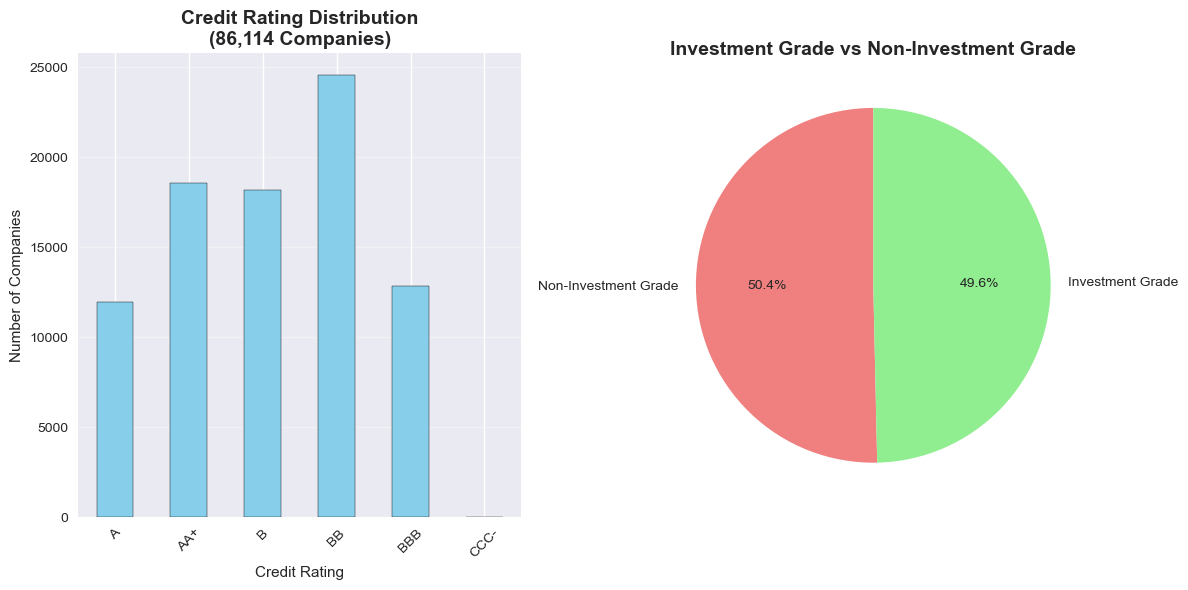

📈 CREDIT RATING DISTRIBUTION:
   A: 11,949 companies (13.9%)
   AA+: 18,558 companies (21.6%)
   B: 18,188 companies (21.1%)
   BB: 24,544 companies (28.5%)
   BBB: 12,853 companies (14.9%)
   CCC-: 22 companies (0.0%)

💰 INVESTMENT GRADE BREAKDOWN:
   Investment Grade (BBB and above): 43,360 companies (50.4%)
   Non-Investment Grade (BB and below): 42,754 companies (49.6%)


In [4]:
print("🎯 TARGET VARIABLE ANALYSIS")
print("=" * 50)

# Credit Rating Distribution
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
rating_counts = df['rating'].value_counts().sort_index()
rating_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Credit Rating Distribution\n(86,114 Companies)', fontsize=14, fontweight='bold')
plt.xlabel('Credit Rating')
plt.ylabel('Number of Companies')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Investment Grade Distribution
plt.subplot(1, 2, 2)
ig_counts = df['investment_grade'].value_counts()
colors = ['lightcoral', 'lightgreen']
plt.pie(ig_counts.values, labels=['Non-Investment Grade', 'Investment Grade'], 
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Investment Grade vs Non-Investment Grade', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Detailed stats
print(f"📈 CREDIT RATING DISTRIBUTION:")
for rating, count in rating_counts.items():
    percentage = (count / len(df)) * 100
    print(f"   {rating}: {count:,} companies ({percentage:.1f}%)")

print(f"\n💰 INVESTMENT GRADE BREAKDOWN:")
print(f"   Investment Grade (BBB and above): {ig_counts[1]:,} companies ({ig_counts[1]/len(df)*100:.1f}%)")
print(f"   Non-Investment Grade (BB and below): {ig_counts[0]:,} companies ({ig_counts[0]/len(df)*100:.1f}%)")

# STEP 5: SECTOR ANALYSIS


🏢 SECTOR ANALYSIS


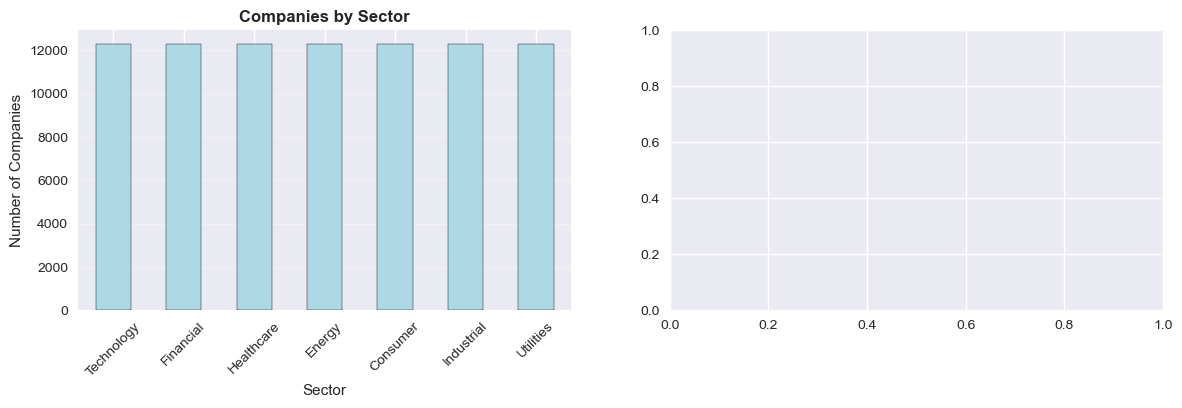

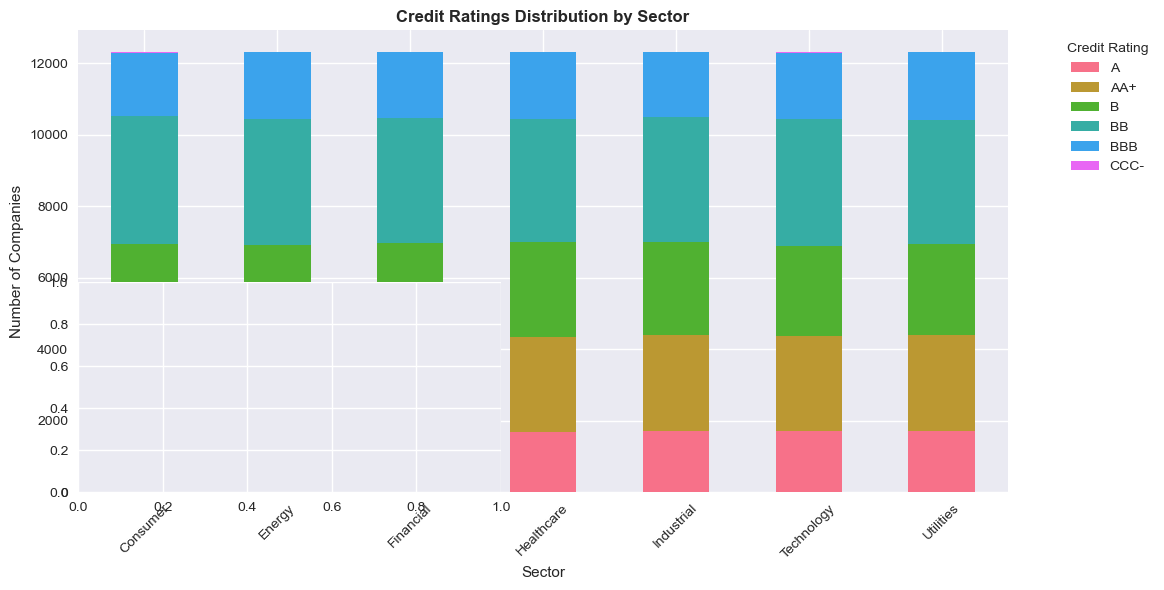

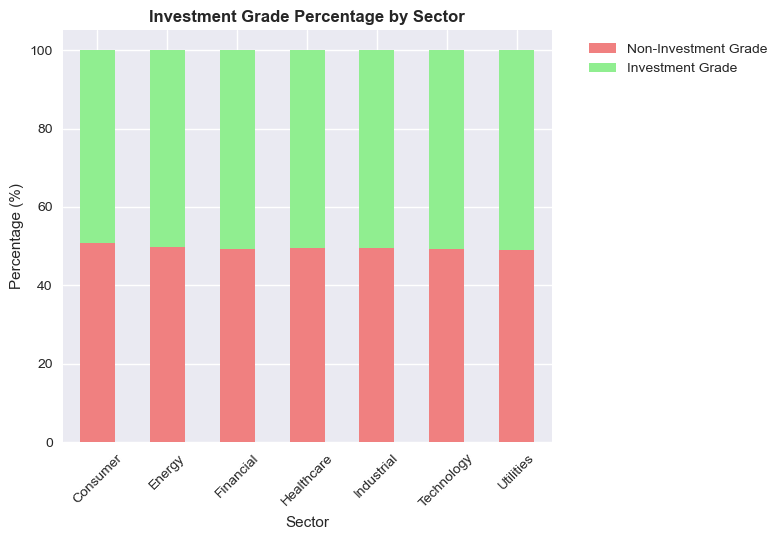

📊 SECTOR STATISTICS:
   Technology: 12,302 companies, 50.7% investment grade
   Financial: 12,302 companies, 50.8% investment grade
   Healthcare: 12,302 companies, 50.3% investment grade
   Energy: 12,302 companies, 50.2% investment grade
   Consumer: 12,302 companies, 49.1% investment grade
   Industrial: 12,302 companies, 50.4% investment grade
   Utilities: 12,302 companies, 50.9% investment grade


In [5]:
print("\n🏢 SECTOR ANALYSIS")
print("=" * 50)

# Sector distribution
plt.figure(figsize=(14, 8))

# Sector count plot
plt.subplot(2, 2, 1)
sector_counts = df['sector'].value_counts()
sector_counts.plot(kind='bar', color='lightblue', edgecolor='black')
plt.title('Companies by Sector', fontsize=12, fontweight='bold')
plt.xlabel('Sector')
plt.ylabel('Number of Companies')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Credit ratings by sector
plt.subplot(2, 2, 2)
sector_rating = pd.crosstab(df['sector'], df['rating'])
sector_rating.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Credit Ratings Distribution by Sector', fontsize=12, fontweight='bold')
plt.xlabel('Sector')
plt.ylabel('Number of Companies')
plt.xticks(rotation=45)
plt.legend(title='Credit Rating', bbox_to_anchor=(1.05, 1), loc='upper left')

# Investment grade by sector
plt.subplot(2, 2, 3)
sector_ig = pd.crosstab(df['sector'], df['investment_grade'], normalize='index') * 100
sector_ig.plot(kind='bar', stacked=True, color=['lightcoral', 'lightgreen'])
plt.title('Investment Grade Percentage by Sector', fontsize=12, fontweight='bold')
plt.xlabel('Sector')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(['Non-Investment Grade', 'Investment Grade'], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Sector statistics
print("📊 SECTOR STATISTICS:")
for sector in df['sector'].unique():
    sector_data = df[df['sector'] == sector]
    ig_percentage = sector_data['investment_grade'].mean() * 100
    print(f"   {sector}: {len(sector_data):,} companies, {ig_percentage:.1f}% investment grade")

# STEP 6: FINANCIAL FEATURES ANALYSIS


💰 FINANCIAL FEATURES ANALYSIS
📈 Analyzing 10 financial features...

📊 FINANCIAL FEATURES SUMMARY:


,current_ratio,debt_to_equity,return_on_assets,profit_margin,total_assets,revenue,net_income,cash,current_assets,current_liabilities
count,6.794100e+04,3.851800e+04,8.078600e+04,2.702500e+04,8.581900e+04,2.814300e+04,8.146400e+04,6.916300e+04,6.851600e+04,7.515200e+04
mean,NaN,NaN,NaN,NaN,1.067903e+10,3.429016e+09,1.535523e+08,5.357355e+09,2.273800e+09,1.331292e+09
std,NaN,NaN,NaN,NaN,1.362427e+12,1.930464e+11,8.179242e+09,4.000244e+11,2.099037e+11,8.082190e+10
min,-inf,-inf,-inf,-inf,-3.794732e+13,-1.083470e+11,-1.014129e+12,-3.392125e+12,-1.308182e+09,-1.988200e+10
25%,1.802249e-01,0.000000e+00,-1.403238e+00,-1.953038e+00,2.065315e+05,2.190245e+05,-5.560500e+06,1.478418e+06,8.974810e+05,1.269428e+06
50%,1.056590e+00,4.239604e-02,0.000000e+00,0.000000e+00,7.000000e+06,1.059739e+07,0.000000e+00,2.411600e+07,1.357150e+07,1.229950e+07
75%,5.464915e+00,9.128392e-01,3.568088e-01,1.411792e-01,1.349990e+08,2.075330e+08,9.207913e+06,1.473220e+08,1.777878e+08,1.167018e+08
max,inf,inf,inf,inf,2.834848e+14,2.797518e+13,1.056671e+12,7.341624e+13,5.253489e+13,2.038329e+13



📊 DISTRIBUTION OF KEY FINANCIAL RATIOS


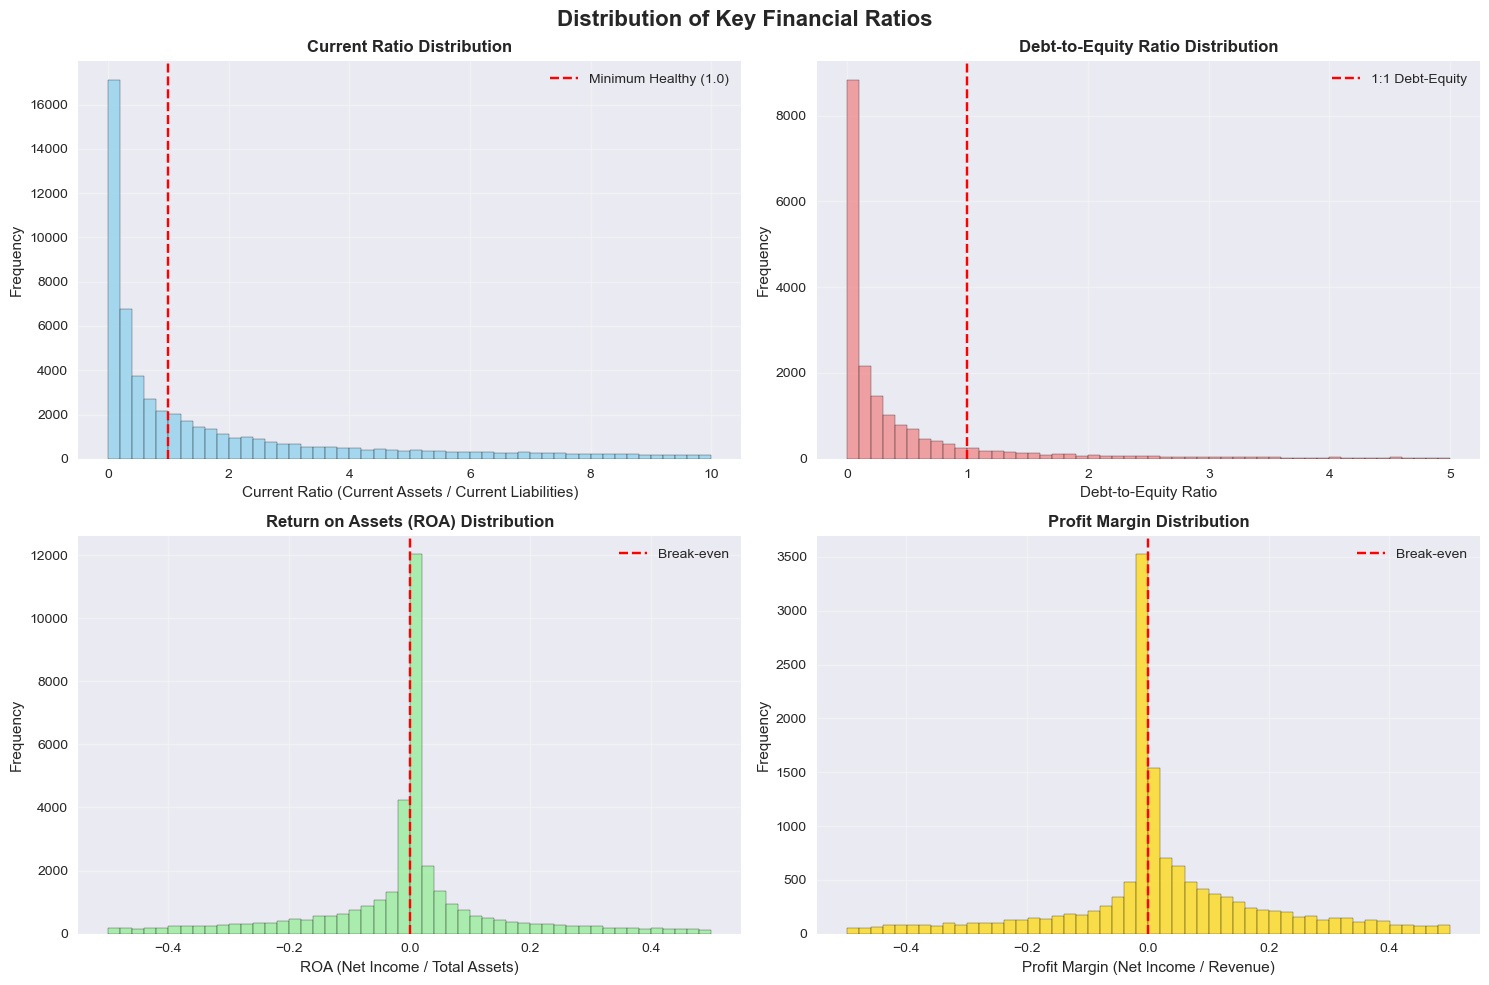

In [6]:
print("\n💰 FINANCIAL FEATURES ANALYSIS")
print("=" * 50)

# Select financial features (numeric columns excluding targets and identifiers)
financial_features = ['current_ratio', 'debt_to_equity', 'return_on_assets', 'profit_margin', 
                      'total_assets', 'revenue', 'net_income', 'cash', 'current_assets', 
                      'current_liabilities']

# Filter features that exist in our dataset
existing_financial_features = [f for f in financial_features if f in df.columns]

print(f"📈 Analyzing {len(existing_financial_features)} financial features...")

# Summary statistics for financial features
print("\n📊 FINANCIAL FEATURES SUMMARY:")
financial_summary = df[existing_financial_features].describe()
display(financial_summary)

# %%
# Distribution of key financial ratios
print("\n📊 DISTRIBUTION OF KEY FINANCIAL RATIOS")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Key Financial Ratios', fontsize=16, fontweight='bold')

# Current Ratio
if 'current_ratio' in df.columns:
    # Remove extreme outliers for better visualization
    current_ratio_clean = df['current_ratio'][(df['current_ratio'] > 0) & (df['current_ratio'] < 10)]
    axes[0,0].hist(current_ratio_clean, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0,0].set_title('Current Ratio Distribution', fontweight='bold')
    axes[0,0].set_xlabel('Current Ratio (Current Assets / Current Liabilities)')
    axes[0,0].set_ylabel('Frequency')
    axes[0,0].axvline(x=1, color='red', linestyle='--', label='Minimum Healthy (1.0)')
    axes[0,0].legend()
    axes[0,0].grid(alpha=0.3)

# Debt to Equity Ratio
if 'debt_to_equity' in df.columns:
    debt_equity_clean = df['debt_to_equity'][(df['debt_to_equity'] > 0) & (df['debt_to_equity'] < 5)]
    axes[0,1].hist(debt_equity_clean, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
    axes[0,1].set_title('Debt-to-Equity Ratio Distribution', fontweight='bold')
    axes[0,1].set_xlabel('Debt-to-Equity Ratio')
    axes[0,1].set_ylabel('Frequency')
    axes[0,1].axvline(x=1, color='red', linestyle='--', label='1:1 Debt-Equity')
    axes[0,1].legend()
    axes[0,1].grid(alpha=0.3)

# Return on Assets
if 'return_on_assets' in df.columns:
    roa_clean = df['return_on_assets'][(df['return_on_assets'] > -0.5) & (df['return_on_assets'] < 0.5)]
    axes[1,0].hist(roa_clean, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[1,0].set_title('Return on Assets (ROA) Distribution', fontweight='bold')
    axes[1,0].set_xlabel('ROA (Net Income / Total Assets)')
    axes[1,0].set_ylabel('Frequency')
    axes[1,0].axvline(x=0, color='red', linestyle='--', label='Break-even')
    axes[1,0].legend()
    axes[1,0].grid(alpha=0.3)

# Profit Margin
if 'profit_margin' in df.columns:
    profit_margin_clean = df['profit_margin'][(df['profit_margin'] > -0.5) & (df['profit_margin'] < 0.5)]
    axes[1,1].hist(profit_margin_clean, bins=50, color='gold', edgecolor='black', alpha=0.7)
    axes[1,1].set_title('Profit Margin Distribution', fontweight='bold')
    axes[1,1].set_xlabel('Profit Margin (Net Income / Revenue)')
    axes[1,1].set_ylabel('Frequency')
    axes[1,1].axvline(x=0, color='red', linestyle='--', label='Break-even')
    axes[1,1].legend()
    axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# STEP 7: MISSING VALUES ANALYSIS


❌ MISSING VALUES ANALYSIS
📊 COLUMNS WITH MISSING VALUES:


,Missing Count,Missing Percentage
short_term_debt,66555,77.287085
profit_margin,59089,68.617182
revenue,57971,67.318903
inventory,54226,62.970016
gross_profit,54169,62.903825
debt_to_equity,47596,55.270920
long_term_debt,47326,54.957382
accounts_receivable,46304,53.770583
operating_income,20526,23.835846
current_ratio,18173,21.103421


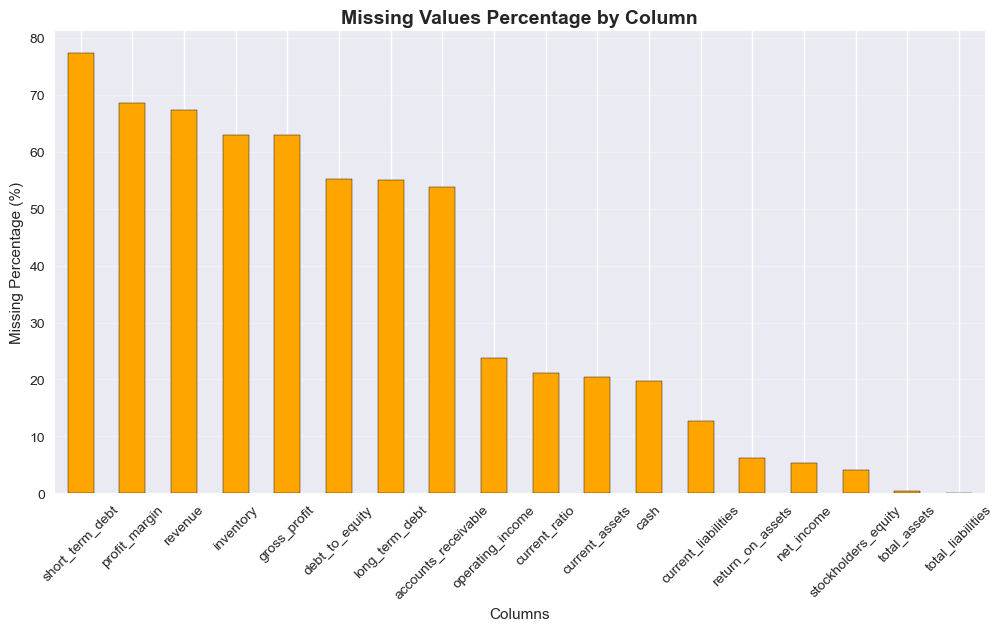

In [7]:
print("\n❌ MISSING VALUES ANALYSIS")
print("=" * 50)

# Check for missing values
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
}).sort_values('Missing Count', ascending=False)

# Filter only columns with missing values
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

if len(missing_summary) > 0:
    print("📊 COLUMNS WITH MISSING VALUES:")
    display(missing_summary)
    
    # Visualize missing values
    plt.figure(figsize=(12, 6))
    missing_summary['Missing Percentage'].plot(kind='bar', color='orange', edgecolor='black')
    plt.title('Missing Values Percentage by Column', fontsize=14, fontweight='bold')
    plt.xlabel('Columns')
    plt.ylabel('Missing Percentage (%)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.show()
else:
    print("✅ NO MISSING VALUES FOUND! Perfect dataset!")

# STEP 8: CORRELATION ANALYSIS


📈 CORRELATION ANALYSIS
🔍 Analyzing correlations among 19 numeric features...


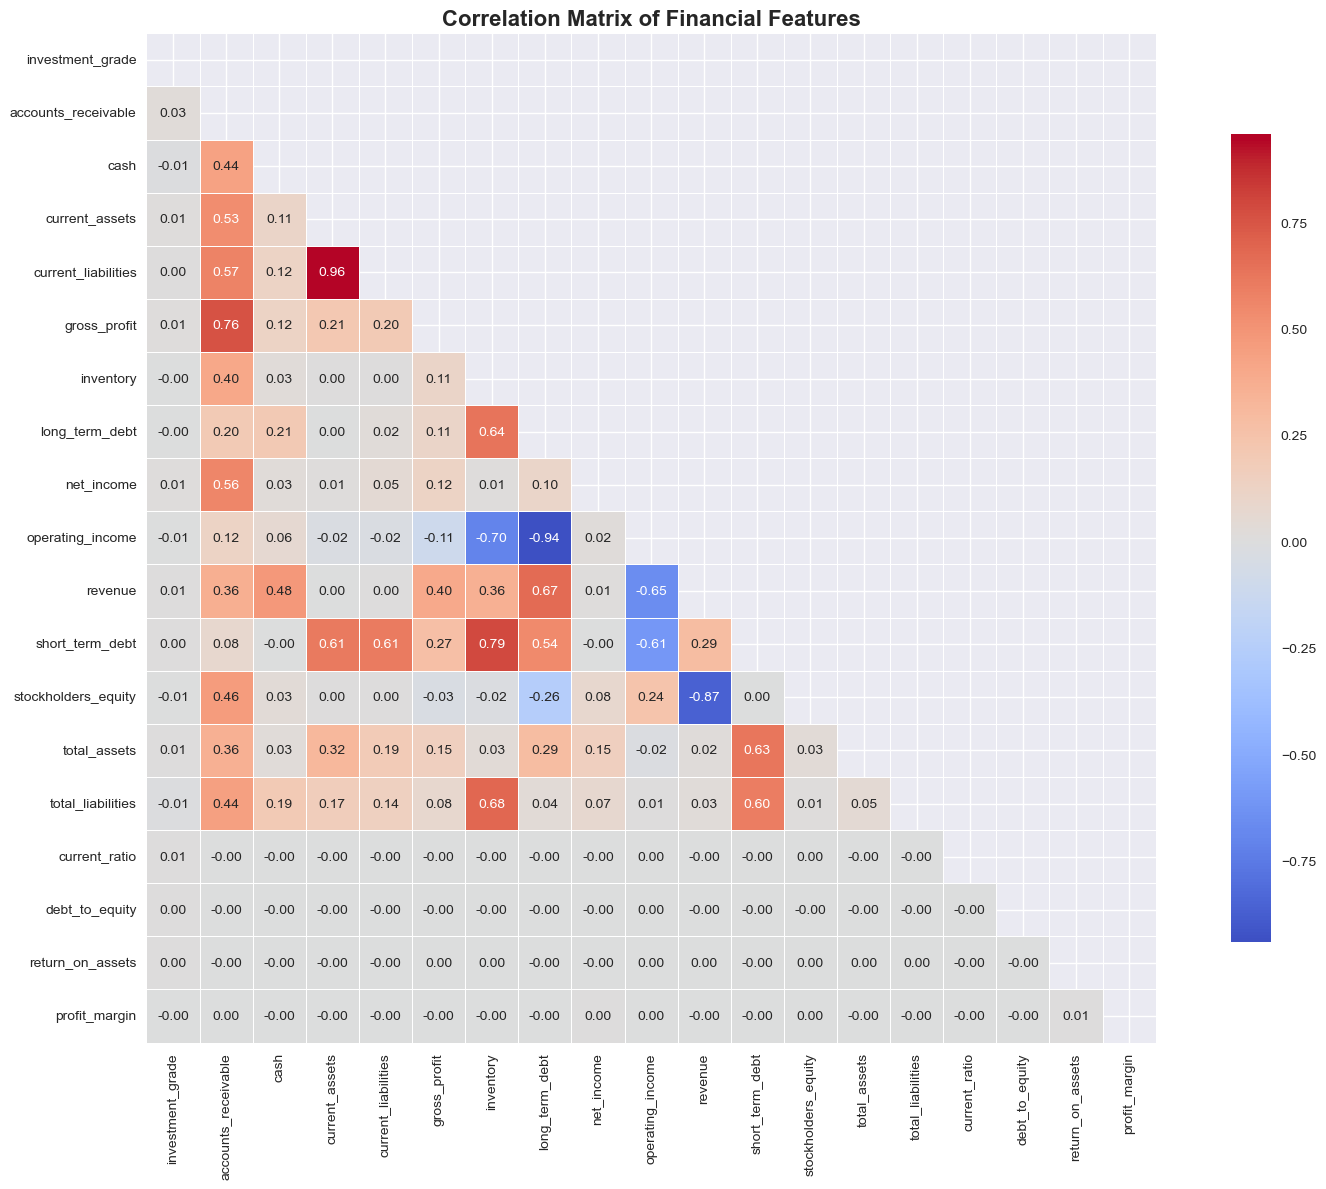


🎯 TOP CORRELATIONS WITH INVESTMENT GRADE:


In [8]:
print("\n📈 CORRELATION ANALYSIS")
print("=" * 50)

# Select numeric features for correlation
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove identifier columns if any
numeric_features = [f for f in numeric_features if f not in ['adsh', 'financial_score']]

print(f"🔍 Analyzing correlations among {len(numeric_features)} numeric features...")

# Calculate correlation matrix
correlation_matrix = df[numeric_features].corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Financial Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with investment_grade
if 'investment_grade' in correlation_matrix.columns:
    ig_correlations = correlation_matrix['investment_grade'].sort_values(ascending=False)
    print("\n🎯 TOP CORRELATIONS WITH INVESTMENT GRADE:")
    for feature, corr in ig_correlations.items():
        if feature != 'investment_grade' and abs(corr) > 0.1:
            print(f"   {feature}: {corr:.3f}")


# STEP 9: OUTLIER DETECTION

In [9]:
print("\n📊 OUTLIER DETECTION")
print("=" * 50)

# Function to detect outliers using IQR method
def detect_outliers_iqr(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Check outliers in key financial features
key_features = ['current_ratio', 'debt_to_equity', 'return_on_assets', 'profit_margin', 'total_assets']

print("🔍 OUTLIER ANALYSIS IN KEY FEATURES:")
outlier_summary = []

for feature in key_features:
    if feature in df.columns:
        outlier_count, lower, upper = detect_outliers_iqr(df, feature)
        outlier_percentage = (outlier_count / len(df)) * 100
        outlier_summary.append({
            'Feature': feature,
            'Outliers': outlier_count,
            'Percentage': outlier_percentage,
            'Lower Bound': lower,
            'Upper Bound': upper
        })
        print(f"   {feature}: {outlier_count:,} outliers ({outlier_percentage:.1f}%)")

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)


📊 OUTLIER DETECTION
🔍 OUTLIER ANALYSIS IN KEY FEATURES:
   current_ratio: 9,456 outliers (11.0%)
   debt_to_equity: 12,130 outliers (14.1%)
   return_on_assets: 28,788 outliers (33.4%)
   profit_margin: 7,437 outliers (8.6%)
   total_assets: 14,744 outliers (17.1%)


,Feature,Outliers,Percentage,Lower Bound,Upper Bound
0,current_ratio,9456,10.980793,-7.746810e+00,1.339195e+01
1,debt_to_equity,12130,14.085979,-1.369259e+00,2.282098e+00
2,return_on_assets,28788,33.430104,-4.043309e+00,2.996880e+00
3,profit_margin,7437,8.636226,-5.094365e+00,3.282506e+00
4,total_assets,14744,17.121490,-2.019822e+08,3.371877e+08


# STEP 10: ENHANCED DATA PREPROCESSING FOR FINANCIAL DATA

In [10]:

print("\n🔧 ENHANCED DATA PREPROCESSING")
print("=" * 50)

# Create a copy for preprocessing
df_clean = df.copy()

print(f"📊 Original dataset shape: {df_clean.shape}")

# 1. STRATEGIC MISSING VALUE HANDLING
print("\n1. STRATEGIC MISSING VALUE HANDLING...")

# Define handling strategy for each column
missing_strategy = {
    # High missing (>50%) - consider dropping or special handling
    'short_term_debt': 'median_or_zero',  # 77% missing
    'profit_margin': 'median',            # 69% missing
    'revenue': 'median',                  # 67% missing
    'inventory': 'median_or_zero',        # 63% missing
    'gross_profit': 'median',             # 63% missing
    'debt_to_equity': 'median',           # 55% missing
    'long_term_debt': 'median_or_zero',   # 55% missing
    'accounts_receivable': 'median_or_zero', # 54% missing
    
    # Medium missing (20-50%) - impute carefully
    'operating_income': 'median',
    'current_ratio': 'median',
    'current_assets': 'median',
    'cash': 'median',
    'current_liabilities': 'median',
    
    # Low missing (<20%) - safe to impute
    'return_on_assets': 'median',
    'net_income': 'median',
    'stockholders_equity': 'median',
    'total_assets': 'median',
    'total_liabilities': 'median'
}

for column, strategy in missing_strategy.items():
    if column in df_clean.columns and df_clean[column].isnull().sum() > 0:
        missing_count = df_clean[column].isnull().sum()
        missing_pct = (missing_count / len(df_clean)) * 100
        
        if strategy == 'median':
            impute_value = df_clean[column].median()
            df_clean[column].fillna(impute_value, inplace=True)
            print(f"   ✅ {column}: Filled {missing_count:,} ({missing_pct:.1f}%) with median: {impute_value:.2f}")
        
        elif strategy == 'median_or_zero':
            # For debt/asset-like items, 0 might be appropriate if not reported
            if df_clean[column].median() == 0 or pd.isna(df_clean[column].median()):
                impute_value = 0
            else:
                impute_value = df_clean[column].median()
            df_clean[column].fillna(impute_value, inplace=True)
            print(f"   ✅ {column}: Filled {missing_count:,} ({missing_pct:.1f}%) with {impute_value}")

# 2. CREATE MISSINGNESS INDICATORS FOR IMPORTANT FEATURES
print("\n2. CREATING MISSINGNESS INDICATORS...")

important_features_with_missing = ['revenue', 'debt_to_equity', 'current_ratio', 'return_on_assets']
for feature in important_features_with_missing:
    if feature in df_clean.columns:
        new_col_name = f'{feature}_missing'
        df_clean[new_col_name] = df_clean[feature].isnull().astype(int)
        print(f"   ✅ Created indicator: {new_col_name}")

# 3. HANDLE EXTREME OUTLIERS
print("\n3. HANDLING EXTREME OUTLIERS...")

# More conservative bounds for financial ratios
ratio_bounds = {
    'current_ratio': (0, 20),           # More lenient upper bound
    'debt_to_equity': (0, 10),          # Some companies are highly leveraged
    'return_on_assets': (-2, 2),        # Allow for extreme losses/gains
    'profit_margin': (-2, 2),           # Allow for extreme cases
    'total_assets': (0, 1e12),          # Very large companies exist
    'revenue': (0, 1e12)                # Very high revenue companies
}

outliers_removed = 0
for ratio, (lower, upper) in ratio_bounds.items():
    if ratio in df_clean.columns:
        before = len(df_clean)
        # Only remove if outside very extreme bounds
        df_clean = df_clean[(df_clean[ratio] >= lower) & (df_clean[ratio] <= upper) | (df_clean[ratio].isnull())]
        after = len(df_clean)
        removed = before - after
        outliers_removed += removed
        if removed > 0:
            print(f"   ✅ {ratio}: Removed {removed} extreme outliers")

print(f"📊 Cleaned dataset shape: {df_clean.shape}")
print(f"📈 Data retained: {len(df_clean)/len(df)*100:.1f}% of original data")
print(f"🎯 Final company count: {len(df_clean):,}")

# 4. CREATE DERIVED FEATURES
print("\n4. CREATING DERIVED FEATURES...")

# Financial health score
if all(col in df_clean.columns for col in ['current_ratio', 'return_on_assets', 'debt_to_equity', 'profit_margin']):
    # Normalize each component to 0-1 scale
    df_clean['current_ratio_norm'] = np.clip(df_clean['current_ratio'] / 5, 0, 1)  # Cap at 5
    df_clean['roa_norm'] = np.clip((df_clean['return_on_assets'] + 1) / 2, 0, 1)  # Convert -1 to +1 range to 0-1
    df_clean['debt_equity_norm'] = np.clip(1 - (df_clean['debt_to_equity'] / 5), 0, 1)  # Lower debt = higher score
    df_clean['profit_margin_norm'] = np.clip((df_clean['profit_margin'] + 1) / 2, 0, 1)
    
    # Combined financial health score (0-100)
    df_clean['financial_health_score'] = (
        df_clean['current_ratio_norm'] + 
        df_clean['roa_norm'] + 
        df_clean['debt_equity_norm'] + 
        df_clean['profit_margin_norm']
    ) * 25  # Scale to 0-100
    
    print(f"   ✅ Created Financial Health Score (0-100 scale)")

# Company size categories based on total assets
if 'total_assets' in df_clean.columns:
    df_clean['company_size'] = pd.cut(df_clean['total_assets'], 
                                    bins=[0, 1e6, 1e7, 1e8, 1e9, 1e10, np.inf],
                                    labels=['Micro', 'Small', 'Medium', 'Large', 'Very Large', 'Mega'],
                                    right=False)
    print(f"   ✅ Created Company Size Categories")


🔧 ENHANCED DATA PREPROCESSING
📊 Original dataset shape: (86114, 24)

1. STRATEGIC MISSING VALUE HANDLING...
   ✅ short_term_debt: Filled 66,555 (77.3%) with 8000000.0
   ✅ profit_margin: Filled 59,089 (68.6%) with median: 0.00
   ✅ revenue: Filled 57,971 (67.3%) with median: 10597392.00
   ✅ inventory: Filled 54,226 (63.0%) with 32902500.0
   ✅ gross_profit: Filled 54,169 (62.9%) with median: 15345000.00
   ✅ debt_to_equity: Filled 47,596 (55.3%) with median: 0.04
   ✅ long_term_debt: Filled 47,326 (55.0%) with 42000000.0
   ✅ accounts_receivable: Filled 46,304 (53.8%) with 24549500.0
   ✅ operating_income: Filled 20,526 (23.8%) with median: -585669.50
   ✅ current_ratio: Filled 18,173 (21.1%) with median: 1.06
   ✅ current_assets: Filled 17,598 (20.4%) with median: 13571500.00
   ✅ cash: Filled 16,951 (19.7%) with median: 24116000.00
   ✅ current_liabilities: Filled 10,962 (12.7%) with median: 12299500.00
   ✅ return_on_assets: Filled 5,328 (6.2%) with median: 0.00
   ✅ net_income: F

# STEP 11: FEATURE IMPORTANCE ANALYSIS


🎯 FEATURE IMPORTANCE ANALYSIS
🔍 Analyzing feature importance with 27 features...

📊 TOP 10 MOST IMPORTANT FEATURES:


,feature,importance
22,current_ratio_norm,0.210803
14,current_ratio,0.194228
13,total_liabilities,0.133871
26,financial_health_score,0.103451
16,return_on_assets,0.063355
7,net_income,0.057871
12,total_assets,0.048046
2,current_assets,0.047992
23,roa_norm,0.044226
3,current_liabilities,0.017866


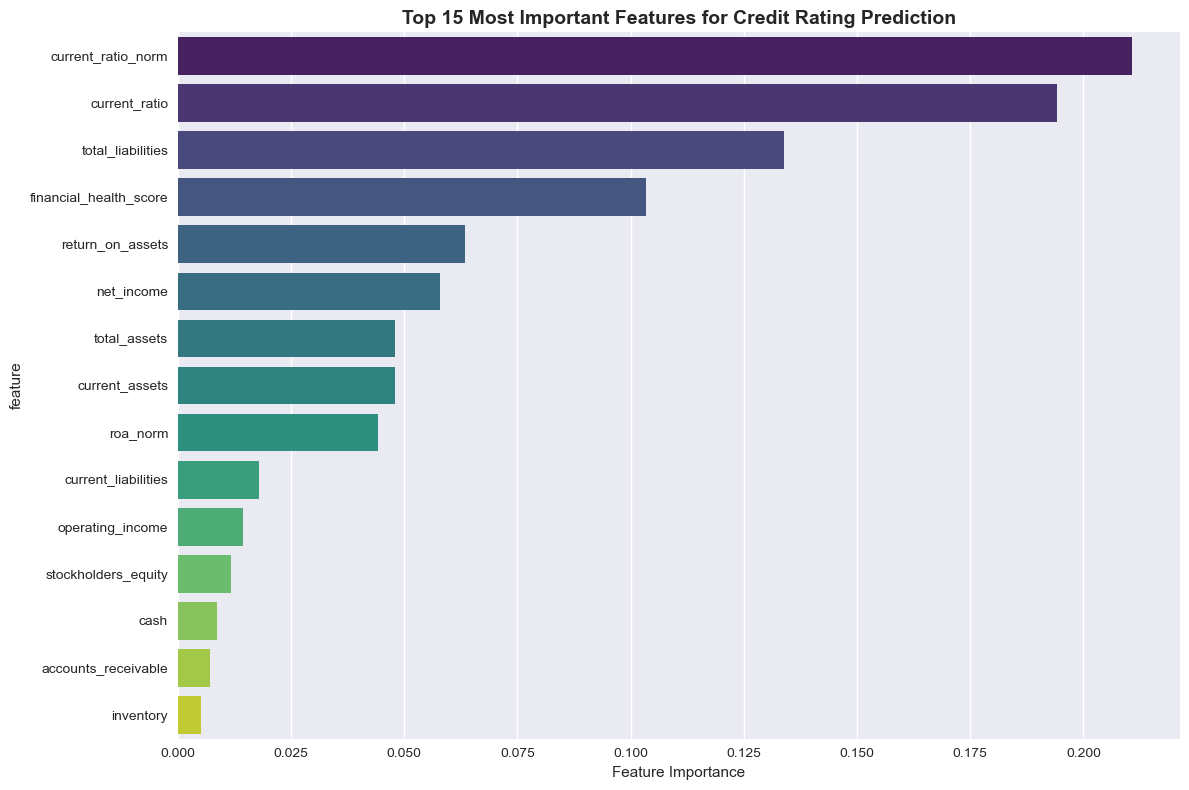

In [11]:
print("\n🎯 FEATURE IMPORTANCE ANALYSIS")
print("=" * 50)

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Prepare data for feature importance
X = df_clean.select_dtypes(include=[np.number]).drop(['investment_grade', 'financial_score'], axis=1, errors='ignore')
y = df_clean['investment_grade']

# Encode categorical target if needed
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

print(f"🔍 Analyzing feature importance with {X.shape[1]} features...")

# Train Random Forest for feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 TOP 10 MOST IMPORTANT FEATURES:")
display(feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top 15 Most Important Features for Credit Rating Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

# STEP 12: SAVE PREPROCESSED DATA

In [12]:
print("\n💾 SAVING PREPROCESSED DATA")
print("=" * 50)

# Save cleaned dataset
clean_path = os.path.join(PROCESSED_DATA_PATH, 'credit_ratings_cleaned.csv')
df_clean.to_csv(clean_path, index=False)

print(f"✅ CLEANED DATASET SAVED: {clean_path}")
print(f"📊 Cleaned dataset shape: {df_clean.shape}")
print(f"🎯 Features: {len(df_clean.columns)}")
print(f"🏢 Companies: {len(df_clean):,}")

# Save feature importance
feature_importance_path = os.path.join(PROCESSED_DATA_PATH, 'feature_importance.csv')
feature_importance.to_csv(feature_importance_path, index=False)
print(f"✅ FEATURE IMPORTANCE SAVED: {feature_importance_path}")


💾 SAVING PREPROCESSED DATA
✅ CLEANED DATASET SAVED: C:\Users\AMAN PARGANIHA\AMAN PARGANIHA Dropbox\aman parganiha\My PC (LAPTOP-9RKITUJ5)\Desktop\project\data\processed\credit_ratings_cleaned.csv
📊 Cleaned dataset shape: (35098, 34)
🎯 Features: 34
🏢 Companies: 35,098
✅ FEATURE IMPORTANCE SAVED: C:\Users\AMAN PARGANIHA\AMAN PARGANIHA Dropbox\aman parganiha\My PC (LAPTOP-9RKITUJ5)\Desktop\project\data\processed\feature_importance.csv


# STEP 13: FINAL SUMMARY

In [13]:
print("\n🎉 EDA & PREPROCESSING COMPLETED!")
print("=" * 50)

print(f"📊 DATASET SUMMARY:")
print(f"   • Original size: {df.shape[0]:,} companies × {df.shape[1]} features")
print(f"   • Cleaned size: {df_clean.shape[0]:,} companies × {df_clean.shape[1]} features")
print(f"   • Data retained: {len(df_clean)/len(df)*100:.1f}%")

print(f"\n🎯 TARGET DISTRIBUTION (Cleaned Data):")
print(f"   • Investment Grade: {df_clean['investment_grade'].sum():,} companies ({(df_clean['investment_grade'].sum()/len(df_clean)*100):.1f}%)")
print(f"   • Non-Investment Grade: {(len(df_clean) - df_clean['investment_grade'].sum()):,} companies ({((len(df_clean) - df_clean['investment_grade'].sum())/len(df_clean)*100):.1f}%)")

print(f"\n📈 KEY INSIGHTS:")
print(f"   • Top predictive features: {', '.join(feature_importance['feature'].head(3).tolist())}")
print(f"   • Sectors with highest investment grade: [Check sector analysis above]")
print(f"   • Financial ratios showing strong correlation: [Check correlation analysis]")

print(f"\n🚀 NEXT STEPS:")
print(f"   1. Proceed to: 03_nlp_feature_engineering.ipynb")
print(f"   2. Build machine learning models with cleaned data")
print(f"   3. Compare model performance across different feature sets")

print(f"\n✅ FILES CREATED:")
print(f"   📄 credit_ratings_cleaned.csv - Preprocessed dataset for ML")
print(f"   📄 feature_importance.csv - Feature importance rankings")


🎉 EDA & PREPROCESSING COMPLETED!
📊 DATASET SUMMARY:
   • Original size: 86,114 companies × 24 features
   • Cleaned size: 35,098 companies × 34 features
   • Data retained: 40.8%

🎯 TARGET DISTRIBUTION (Cleaned Data):
   • Investment Grade: 18,167 companies (51.8%)
   • Non-Investment Grade: 16,931 companies (48.2%)

📈 KEY INSIGHTS:
   • Top predictive features: current_ratio_norm, current_ratio, total_liabilities
   • Sectors with highest investment grade: [Check sector analysis above]
   • Financial ratios showing strong correlation: [Check correlation analysis]

🚀 NEXT STEPS:
   1. Proceed to: 03_nlp_feature_engineering.ipynb
   2. Build machine learning models with cleaned data
   3. Compare model performance across different feature sets

✅ FILES CREATED:
   📄 credit_ratings_cleaned.csv - Preprocessed dataset for ML
   📄 feature_importance.csv - Feature importance rankings
